In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [59]:
df = pd.read_csv("Data/big_mart_sales.csv")
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [60]:
df.shape

(8523, 12)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [62]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [63]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [110]:
sales_median = df["Item_Outlet_Sales"].median()

df["Sales_Class"] = (
    df["Item_Outlet_Sales"] >= sales_median
).astype(int)

print("Sales Median:", sales_median)

print(df["Sales_Class"].value_counts())

Sales Median: 1794.331
Sales_Class
1    4266
0    4257
Name: count, dtype: int64


In [111]:
features = [
    "Item_MRP",
    "Item_Visibility"
]

X = df[features].copy()

y = df["Sales_Class"]

In [112]:
X = X.fillna(X.median())

print(X.isnull().sum())

Item_MRP           0
Item_Visibility    0
dtype: int64


In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (6818, 2)
Testing : (1705, 2)


In [114]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [115]:
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=features,
    index=X_train.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=features,
    index=X_test.index
)

In [117]:
def plot_decision_boundary(model, X, y, title):

    # Create grid
    x_min = X[:, 0].min() - 1
    x_max = X[:, 0].max() + 1

    y_min = X[:, 1].min() - 1
    y_max = X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    # Predict every point in grid
    grid = np.c_[
        xx.ravel(),
        yy.ravel()
    ]

    Z = model.predict(grid)

    Z = Z.reshape(xx.shape)

    # Plot decision regions
    plt.figure(figsize=(9, 7))

    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.3
    )

    # Plot observations
    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolors="k",
        alpha=0.7
    )

    plt.xlabel("Item MRP (Standardized)")
    plt.ylabel("Item Visibility (Standardized)")
    plt.title(title)

    plt.show()

In [118]:
knn_1 = KNeighborsClassifier(
    n_neighbors=1
)

knn_1.fit(
    X_train_scaled,
    y_train
)

KNeighborsClassifier(n_neighbors=1)

In [119]:
y_pred_1 = knn_1.predict(
    X_test_scaled
)

accuracy_1 = accuracy_score(
    y_test,
    y_pred_1
)

print(f"K=1 Accuracy: {accuracy_1:.4f}")

K=1 Accuracy: 0.6804


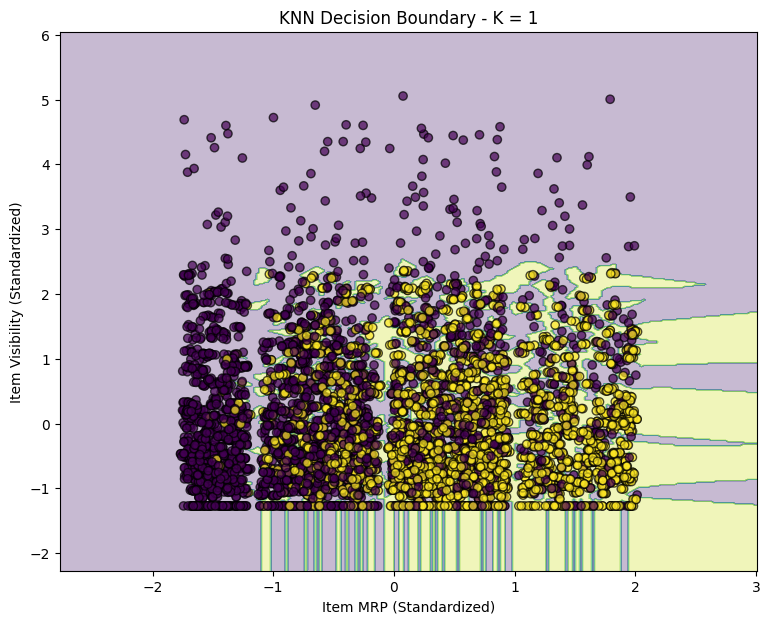

In [120]:
plot_decision_boundary(
    knn_1,
    X_train_scaled,
    y_train,
    "KNN Decision Boundary - K = 1"
)

In [121]:
knn_3 = KNeighborsClassifier(
    n_neighbors=3
)

knn_3.fit(
    X_train_scaled,
    y_train
)

y_pred_3 = knn_3.predict(
    X_test_scaled
)

accuracy_3 = accuracy_score(
    y_test,
    y_pred_3
)

print(f"K=3 Accuracy: {accuracy_3:.4f}")

K=3 Accuracy: 0.6933


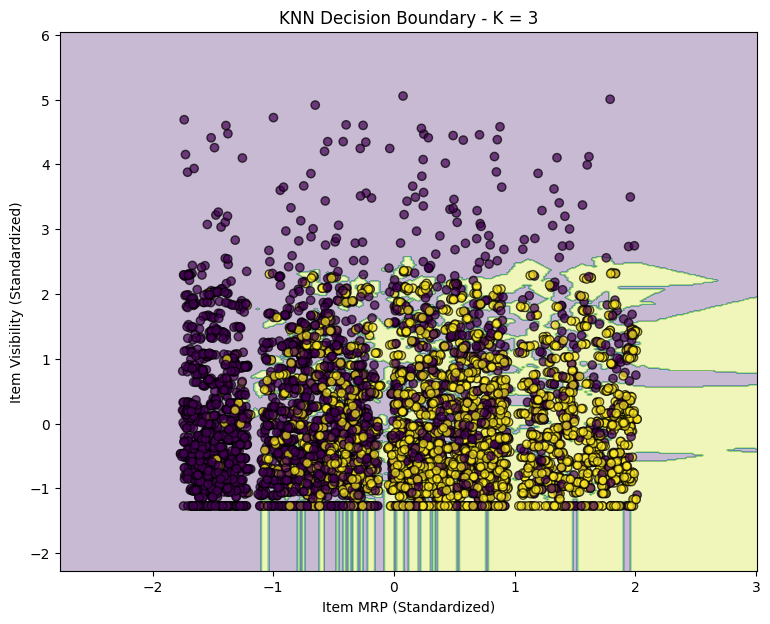

In [122]:
plot_decision_boundary(
    knn_3,
    X_train_scaled,
    y_train,
    "KNN Decision Boundary - K = 3"
)

In [123]:
knn_5 = KNeighborsClassifier(
    n_neighbors=5
)

knn_5.fit(
    X_train_scaled,
    y_train
)

y_pred_5 = knn_5.predict(
    X_test_scaled
)

accuracy_5 = accuracy_score(
    y_test,
    y_pred_5
)

print(f"K=5 Accuracy: {accuracy_5:.4f}")

K=5 Accuracy: 0.7114


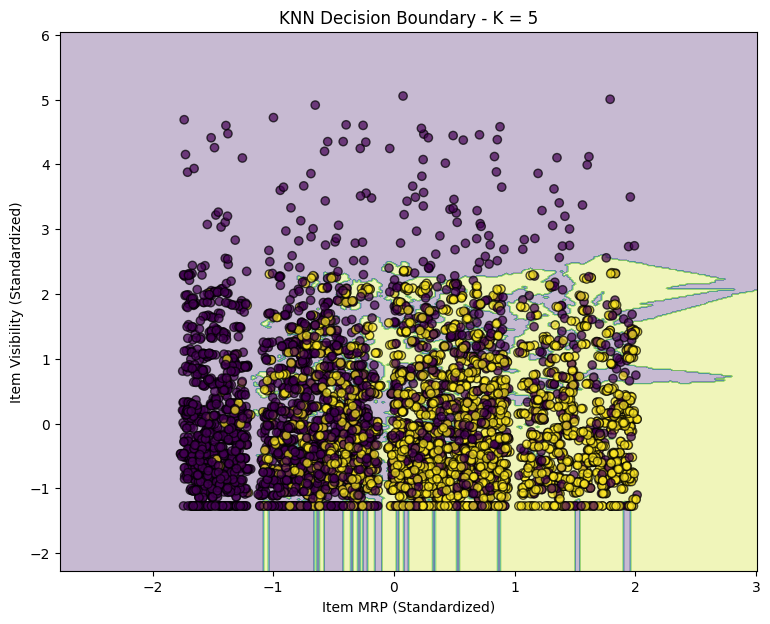

In [124]:
plot_decision_boundary(
    knn_5,
    X_train_scaled,
    y_train,
    "KNN Decision Boundary - K = 5"
)

In [125]:
knn_10 = KNeighborsClassifier(
    n_neighbors=10
)

knn_10.fit(
    X_train_scaled,
    y_train
)

y_pred_10 = knn_10.predict(
    X_test_scaled
)

accuracy_10 = accuracy_score(
    y_test,
    y_pred_10
)

print(f"K=10 Accuracy: {accuracy_10:.4f}")

K=10 Accuracy: 0.7155


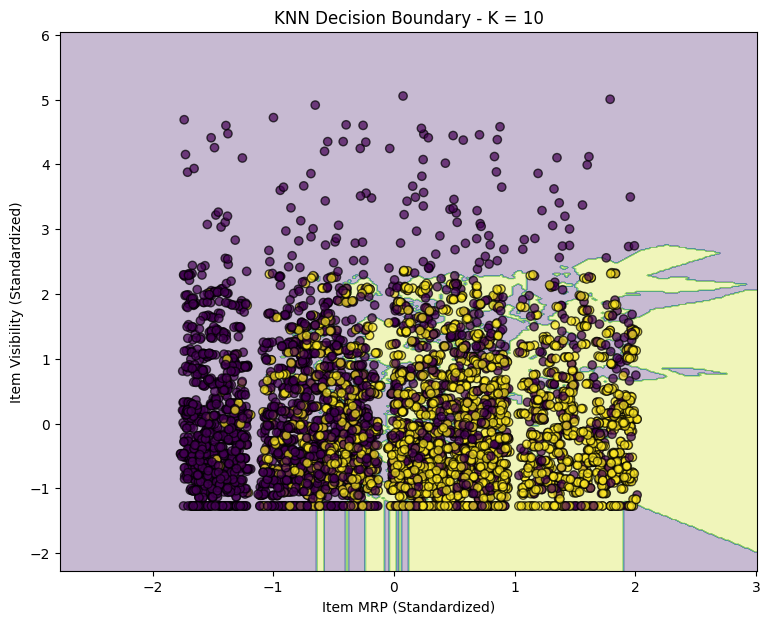

In [126]:
plot_decision_boundary(
    knn_10,
    X_train_scaled,
    y_train,
    "KNN Decision Boundary - K = 10"
)

In [127]:
knn_20 = KNeighborsClassifier(
    n_neighbors=20
)

knn_20.fit(
    X_train_scaled,
    y_train
)

y_pred_20 = knn_20.predict(
    X_test_scaled
)

accuracy_20 = accuracy_score(
    y_test,
    y_pred_20
)

print(f"K=20 Accuracy: {accuracy_20:.4f}")

K=20 Accuracy: 0.7314


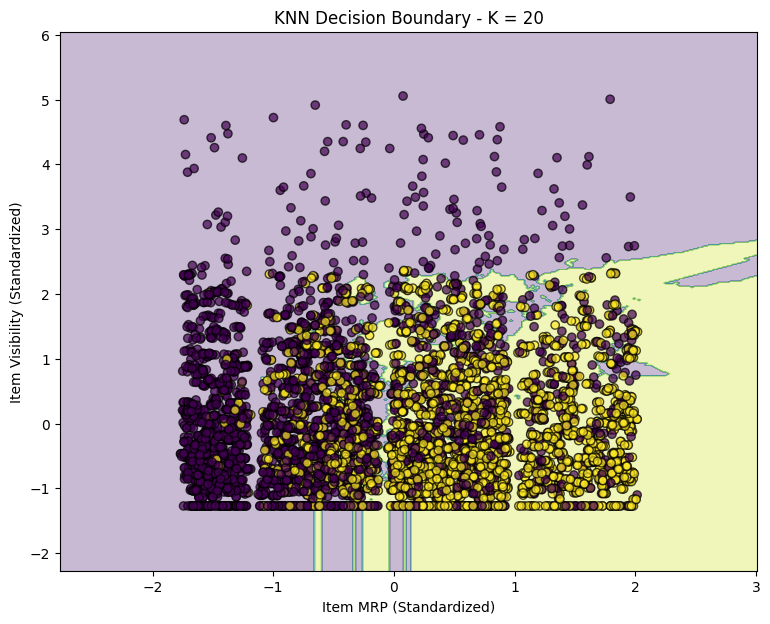

In [128]:
plot_decision_boundary(
    knn_20,
    X_train_scaled,
    y_train,
    "KNN Decision Boundary - K = 20"
)

In [129]:
k_values = [
    1,
    3,
    5,
    10,
    20
]

accuracy_results = []

for k in k_values:

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    prediction = model.predict(
        X_test_scaled
    )

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    accuracy_results.append(accuracy)

    print(
        f"K={k:2d} → "
        f"Accuracy={accuracy:.4f}"
    )

K= 1 → Accuracy=0.6804
K= 3 → Accuracy=0.6933
K= 5 → Accuracy=0.7114
K=10 → Accuracy=0.7155
K=20 → Accuracy=0.7314


In [130]:
results = pd.DataFrame({
    "K": k_values,
    "Accuracy": accuracy_results
})

print(results)

    K  Accuracy
0   1  0.680352
1   3  0.693255
2   5  0.711437
3  10  0.715543
4  20  0.731378


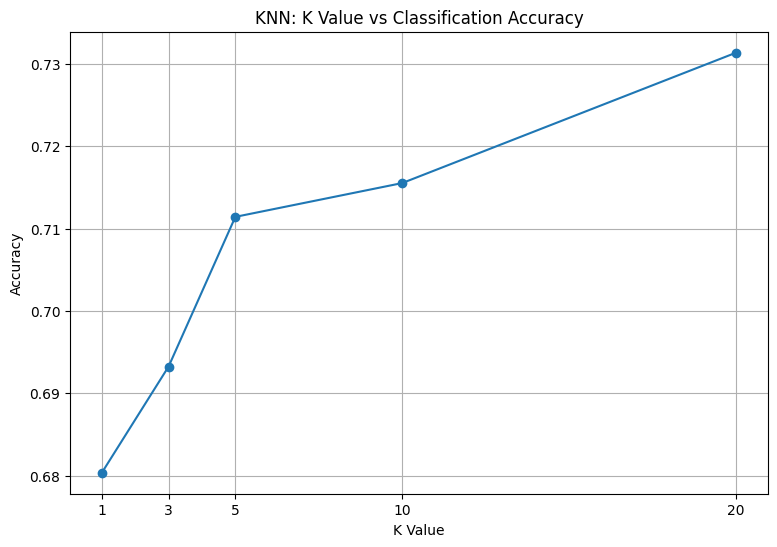

In [131]:
plt.figure(figsize=(9, 6))

plt.plot(
    k_values,
    accuracy_results,
    marker="o"
)

plt.xlabel("K Value")
plt.ylabel("Accuracy")

plt.title(
    "KNN: K Value vs Classification Accuracy"
)

plt.xticks(k_values)

plt.grid(True)

plt.show()

In [132]:
best_index = np.argmax(
    accuracy_results
)

best_k = k_values[best_index]

best_accuracy = accuracy_results[best_index]

print("Best K:", best_k)

print(
    f"Best Accuracy: "
    f"{best_accuracy * 100:.2f}%"
)

Best K: 20
Best Accuracy: 73.14%


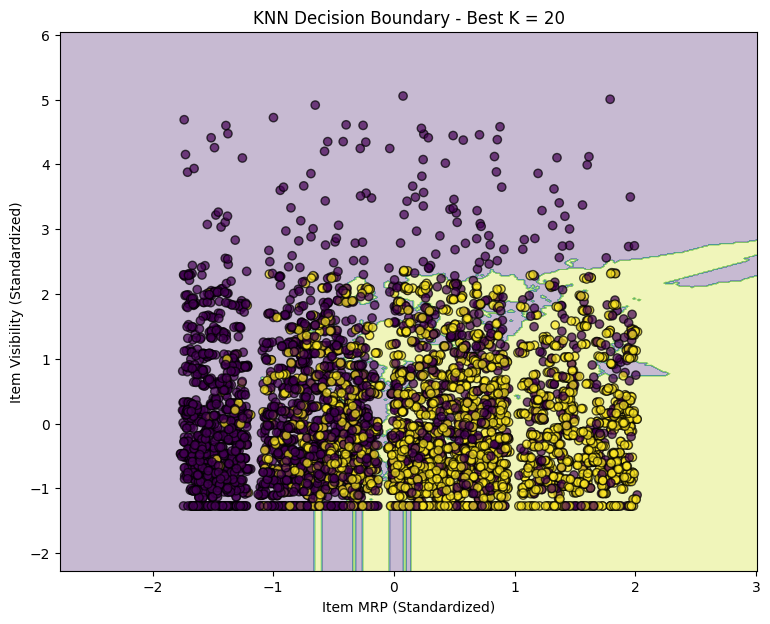

In [133]:
best_knn = KNeighborsClassifier(
    n_neighbors=best_k
)

best_knn.fit(
    X_train_scaled,
    y_train
)

plot_decision_boundary(
    best_knn,
    X_train_scaled,
    y_train,
    f"KNN Decision Boundary - Best K = {best_k}"
)

In [136]:
new_product = pd.DataFrame({
    "Item_MRP": [150],
    "Item_Visibility": [0.05]
})

In [137]:
new_product_scaled = scaler.transform(
    new_product
)

In [138]:
prediction = best_knn.predict(
    new_product_scaled
)

print("Prediction:", prediction)

Prediction: [1]


In [139]:
if prediction[0] == 1:
    print("Prediction: High Sales")
else:
    print("Prediction: Low Sales")

Prediction: High Sales


In [140]:
probability = best_knn.predict_proba(
    new_product_scaled
)

print(probability)

[[0.2 0.8]]
